# Praktikum 2 - Minggu 4: EDA Bivariat dan Laporan Temuan Awal

Mata Kuliah: Data Analitik
CPMK-3 / Sub-CPMK-04

Prasyarat: jalankan Praktikum 1 Minggu 4 terlebih dahulu sehingga file
`data_raw/cuaca_eda_univariat.csv` dan `data_raw/buku_eda_univariat.csv` tersedia.


In [10]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df_cuaca = pd.read_csv("data_raw/cuaca_eda_univariat.csv")
df_buku = pd.read_csv("data_raw/buku_eda_univariat.csv")
df_cuaca["waktu"] = pd.to_datetime(df_cuaca["waktu"])

print("Cuaca:", df_cuaca.shape, "| Buku:", df_buku.shape)
print(df_cuaca.columns.tolist())
print(df_buku.columns.tolist())


Cuaca: (216, 10) | Buku: (100, 6)
['kota', 'waktu', 'suhu_c', 'kelembapan_persen', 'presipitasi_mm', 'kategori_suhu', 'provinsi', 'kabupaten_kota', 'suhu_zscore', 'outlier_suhu_iqr']
['judul', 'harga_numeric', 'rating_numeric', 'tersedia', 'kategori_harga', 'outlier_harga_iqr']


## Bagian A — Analisis Bivariat Numerik-Numerik (Scatter Plot)

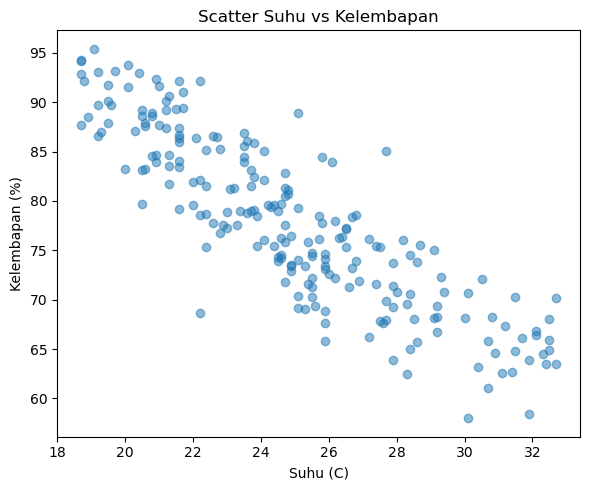

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_cuaca["suhu_c"], df_cuaca["kelembapan_persen"], alpha=0.5)
ax.set_xlabel("Suhu (C)")
ax.set_ylabel("Kelembapan (%)")
ax.set_title("Scatter Suhu vs Kelembapan")
plt.tight_layout()
plt.savefig("data_raw/scatter_suhu_kelembapan.png", dpi=150)
plt.show()

## Bagian B — Analisis Bivariat Numerik-Kategorikal (Groupby)

In [12]:
ringkasan_kota = df_cuaca.groupby("kota")["suhu_c"].agg(["mean", "median", "std"])
print("Ringkasan suhu per kota:")
print(ringkasan_kota)

ringkasan_rating = df_buku.groupby("rating_numeric")["harga_numeric"].agg(["mean", "count"])
print("\nRata-rata harga per rating:")
print(ringkasan_rating)

ringkasan_kategori_harga = df_buku.groupby("kategori_harga")["harga_numeric"].mean()
print("\nRata-rata harga per kategori harga:")
print(ringkasan_kategori_harga)


Ringkasan suhu per kota:
                      mean  median       std
kota                                        
Balige           22.237500    22.2  2.351891
Medan            27.894444    27.7  3.185260
Pematangsiantar  24.562500    24.7  2.789994

Rata-rata harga per rating:
                     mean  count
rating_numeric                  
1               39.207273     11
2               35.550909     22
3               35.073056     36
4               35.818000     15
5               28.174375     16

Rata-rata harga per kategori harga:
kategori_harga
Mahal     49.497209
Murah     15.265000
Sedang    29.374242
Name: harga_numeric, dtype: float64


## Bagian C — Correlation Heatmap

                     suhu_c  kelembapan_persen  presipitasi_mm
suhu_c             1.000000          -0.870789        0.034946
kelembapan_persen -0.870789           1.000000       -0.116991
presipitasi_mm     0.034946          -0.116991        1.000000


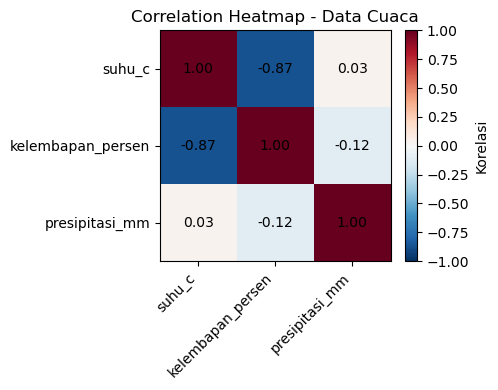


Korelasi rating vs harga buku: -0.172


In [13]:
kolom_numerik = ["suhu_c", "kelembapan_persen", "presipitasi_mm"]
corr = df_cuaca[kolom_numerik].corr()
print(corr)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(kolom_numerik)))
ax.set_xticklabels(kolom_numerik, rotation=45, ha="right")
ax.set_yticks(range(len(kolom_numerik)))
ax.set_yticklabels(kolom_numerik)
for i in range(len(kolom_numerik)):
    for j in range(len(kolom_numerik)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")
fig.colorbar(im, ax=ax, label="Korelasi")
ax.set_title("Correlation Heatmap - Data Cuaca")
plt.tight_layout()
plt.savefig("data_raw/heatmap_korelasi_cuaca.png", dpi=150)
plt.show()

korelasi_rating_harga = df_buku["rating_numeric"].corr(df_buku["harga_numeric"])
print("\nKorelasi rating vs harga buku:", round(korelasi_rating_harga, 3))


## Bagian D — Menyusun Laporan Temuan Awal

In [14]:
print("=== RINGKASAN UNTUK LAPORAN TEMUAN AWAL ===")
print("Rata-rata suhu per kota:")
print(df_cuaca.groupby("kota")["suhu_c"].mean().round(2))
print("\nJumlah outlier suhu (IQR):", int(df_cuaca["outlier_suhu_iqr"].sum()), "dari", len(df_cuaca), "baris")
print("Korelasi suhu vs kelembapan:", round(df_cuaca["suhu_c"].corr(df_cuaca["kelembapan_persen"]), 3))
print("Korelasi rating vs harga buku:", round(df_buku["rating_numeric"].corr(df_buku["harga_numeric"]), 3))


=== RINGKASAN UNTUK LAPORAN TEMUAN AWAL ===
Rata-rata suhu per kota:
kota
Balige             22.24
Medan              27.89
Pematangsiantar    24.56
Name: suhu_c, dtype: float64

Jumlah outlier suhu (IQR): 0 dari 216 baris
Korelasi suhu vs kelembapan: -0.871
Korelasi rating vs harga buku: -0.172


**Contoh laporan temuan awal (kerangka 3 elemen: angka konkret, konteks pembanding, implikasi):**

- **Temuan 1.** Rata-rata suhu di Medan lebih tinggi sekitar 5-6°C dibandingkan Balige dan Pematangsiantar. Selisih ini konsisten pada seluruh rentang data yang diamati. Rekomendasi suhu nyaman untuk wisata Danau Toba sebaiknya dibedakan per kota.
- **Temuan 2.** Korelasi suhu dan kelembapan tergolong lemah, berbeda dari asumsi umum. Variabel lain (presipitasi, waktu pengukuran) kemungkinan lebih berpengaruh terhadap kelembapan.

## Tugas Praktikum 2 Minggu 4

Lihat modul lengkap untuk instruksi tugas dan matriks penilaian. Ringkasnya: pilih pasangan
variabel numerik-numerik dan numerik-kategorikal lain, hitung korelasinya, dan susun laporan
temuan awal minimal 2 temuan dengan kerangka 3 elemen, ditutup dengan refleksi keterbatasan.


## Bagian E — Studi Kasus: EDA Bivariat UMKM Toba

Dataset `data_raw/penjualan_toba_bersih.csv` (dengan kolom outlier dari Bagian E Praktikum 1
Minggu 4) sekarang dianalisis secara bivariat: kategori produk dan cabang mana yang paling
berkontribusi terhadap omzet, dan apakah rating pelanggan berhubungan dengan nilai transaksi?

## Lengkapi Source Code dbawah ini menjadi utuh


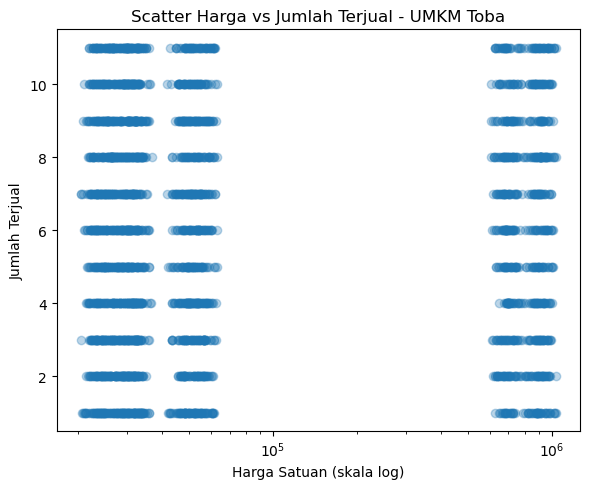

In [15]:
df_umkm = pd.read_csv("data_raw/penjualan_toba_bersih.csv")

# Scatter (log scale, karena rentang harga sangat lebar antar kategori)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_umkm["harga_satuan"], df_umkm["jumlah_terjual"], alpha=0.3)
ax.set_xscale("log")
ax.set_xlabel("Harga Satuan (skala log)")
ax.set_ylabel("Jumlah Terjual")
ax.set_title("Scatter Harga vs Jumlah Terjual - UMKM Toba")
plt.tight_layout()
plt.savefig("data_raw/scatter_umkm_harga_jumlah.png", dpi=150)
plt.show()

In [16]:
# Groupby: omzet per kategori, cabang, metode bayar
print(df_umkm.groupby("kategori")["total_penjualan"].agg(["mean", "sum", "count"]))
print(df_umkm.groupby("cabang")["total_penjualan"].agg(["mean", "sum"]))
print(df_umkm.groupby("metode_bayar")["total_penjualan"].mean())

# Korelasi rating pelanggan vs nilai transaksi
print("Korelasi rating vs total_penjualan:", df_umkm["rating_pelanggan"].corr(df_umkm["total_penjualan"]))

KeyError: 'Column not found: total_penjualan'

Dua pelajaran dari kasus ini: (1) korelasi harga vs jumlah terjual dan rating vs omzet
keduanya mendekati nol — godaan membuat cerita sebab-akibat ("harga murah = laris", "rating tinggi
= omzet besar") harus ditahan karena datanya tidak mendukung; (2) kategori Kerajinan menyumbang
omzet jauh lebih besar dari kategori lain meski volume transaksinya sebanding — wawasan bisnis
nyata untuk UMKM. Terapkan kerangka 3 elemen dari modul teori pada temuan ini.

## Tugas Praktikum 2 Minggu 4 (versi UMKM Toba)

Gunakan dataset UMKM Toba. Buat scatter plot harga_satuan vs jumlah_terjual per kategori produk
pilihan Anda, satu pasangan numerik-kategorikal lain (misalnya total_penjualan per metode_bayar),
hitung korelasinya, dan susun laporan temuan awal (kerangka 3 elemen) + refleksi keterbatasan.
Lihat modul lengkap untuk instruksi dan rubrik penilaian.
